####  B Vidakovic Quantum Framework for Wavelet Shrinkage 
## Example 4

# Quantum Wavelet Denoising (N = 1024) — Classical + Aer Simulation

This notebook demonstrates a **hybrid quantum–classical denoising pipeline**, in which a classical wavelet transform prepares the data for a **quantum-inspired shrinkage** step implemented via Aer simulation. The workflow integrates traditional wavelet denoising principles with concepts from quantum information theory, such as amplitude encoding and Kraus-operator dynamics.

---

## Overview of the Pipeline

1. **Generate a Doppler signal.**  
   We construct a 1024-sample Donoho–Johnstone *Doppler* test signal:  
   $$
   x(t) = \sqrt{t(1-t)} \, \sin\!\left(\frac{2\pi \times 1.05}{t + 0.05}\right),
   \quad 0 \le t < 1.
   $$
   Gaussian noise is added to achieve a **linear SNR of 7**, i.e.,
   $$
   \text{SNR} = \frac{\mathbb{E}[x^2]}{\mathbb{E}[(x - y)^2]} = 7.
   $$

2. **Perform the classical discrete wavelet transform (DWT).**  
   Using the **Symmlet-4** orthogonal wavelet basis (four vanishing moments), we apply
   $$
   \bm{w} = W_{\text{sym4}}\, \bm{y},
   $$
   where $\bm{y}$ is the noisy signal and $\bm{w}$ are its wavelet coefficients.
   These coefficients preserve orthogonality, allowing us to use Parseval’s energy relations.

3. **Estimate noise variance and select a threshold.**  
   The noise level in the wavelet domain is estimated from the finest-scale detail coefficients:
   $$
   \hat{\sigma}_{\text{encoded_


In [7]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

try:
    import pywt
except ImportError as e:
    raise RuntimeError("Please install PyWavelets: pip install pywavelets") from e

# Optional: Aer for state initialization demo
try:
    from qiskit_aer import AerSimulator
    from qiskit import QuantumCircuit, transpile
    from qiskit.quantum_info import Statevector
    HAVE_AER = True
except Exception:
    HAVE_AER = False
    print("Qiskit Aer not found. The notebook will still run the full pipeline.\n"
          "Install with: pip install qiskit qiskit-aer")


## 1) Generate Doppler signal and add noise at linear SNR = 7

In [8]:
N = 1024
t = np.linspace(0, 1, N, endpoint=False)

# Donoho–Johnstone Doppler
doppler = np.sqrt(t*(1-t)) * np.sin((2*np.pi*1.05)/(t+0.05))
doppler -= doppler.mean()

# Add Gaussian noise with desired linear SNR
SNR_linear = 7.0
sig_power = np.mean(doppler**2)
noise_power = sig_power / SNR_linear
sigma_noise = np.sqrt(noise_power)
rng = np.random.default_rng(1234)
noise = rng.normal(0.0, sigma_noise, size=N)
y_noisy = doppler + noise

def snr_db(clean, est):
    return 10*np.log10(np.sum(clean**2) / (np.sum((clean-est)**2) + 1e-15))

print("Noisy SNR (dB):", round(snr_db(doppler, y_noisy), 2))


Noisy SNR (dB): 8.36


## 2) Classical Symmlet-4 forward transform and noise estimate

In [9]:
wavelet = pywt.Wavelet('sym4')
max_level = pywt.dwt_max_level(N, wavelet.dec_len)
coeffs = pywt.wavedec(y_noisy, wavelet=wavelet, level=max_level, mode='periodization')
w_array, w_slices = pywt.coeffs_to_array(coeffs)

# Estimate sigma from finest details via MAD / 0.6745
cD1 = coeffs[-1]
sigma_encoded = np.median(np.abs(cD1 - np.median(cD1))) / 0.6745
tau = 2.5 * sigma_encoded
print("Estimated sigma_encoded:", round(sigma_encoded, 4), "  tau:", round(tau, 4))


Estimated sigma_encoded: 0.1131   tau: 0.2827


## 3) Amplitude encoding of 1024 coefficients
We normalize the coefficient vector to get $|w\rangle$.
If Aer is available, we show a short state initialization demo.

In [10]:
w = w_array.astype(float)
norm_w = np.linalg.norm(w) + 1e-15
psi = w / norm_w

if HAVE_AER:
    # Minimal statevector init demo (no full state preparation circuit here).
    # We create a trivial qc with no gates and use Statevector directly.
    sv = Statevector(psi)
    print("Statevector length:", len(sv.data))
else:
    print("Skipping Aer demo; proceeding with numpy statevector.")


Statevector length: 1024


## 4) Kraus-style shrinkage (postselected diagonal)
We apply $K_0 = \mathrm{diag}(\sqrt{a_i})$ with $a_i = \max(0, 1 - \tau/|w_i|)$ to the normalized state, then renormalize.

In [11]:
abs_w = np.abs(w) + 1e-15
a = np.maximum(0.0, 1.0 - tau/abs_w)
K0_diag = np.sqrt(a)

psi_post = K0_diag * psi
psi_post /= (np.linalg.norm(psi_post) + 1e-15)

# Map back to coefficient scale
w_kraus = psi_post * norm_w

# Classical soft-threshold for comparison
w_soft = np.sign(w) * np.maximum(abs_w - tau, 0.0)

print("Nonzeros after soft-threshold:", int(np.count_nonzero(w_soft)))
print("Effective shrinkage mean a_i:", float(a.mean()))


Nonzeros after soft-threshold: 49
Effective shrinkage mean a_i: 0.02119775456876169


## 5) Inverse transform and comparison

SNR noisy (dB): 8.36
SNR soft  (dB): 14.15
SNR K0    (dB): 15.18


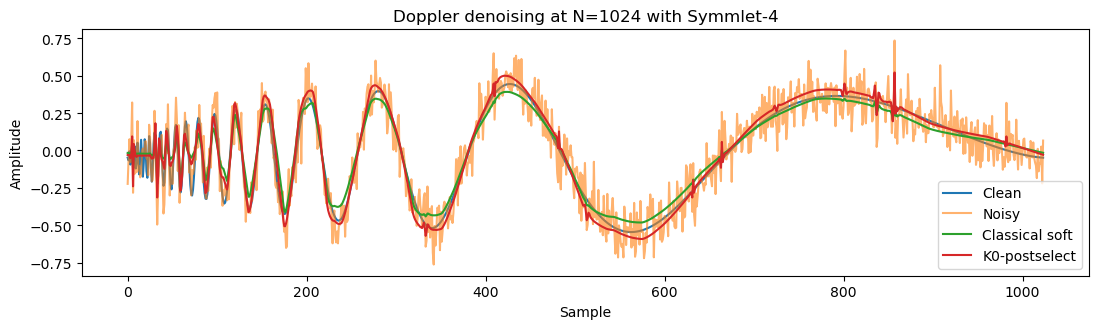

In [12]:
# Build coeff lists and invert
coeffs_soft = pywt.array_to_coeffs(w_soft, w_slices, output_format='wavedec')
coeffs_kraus = pywt.array_to_coeffs(w_kraus, w_slices, output_format='wavedec')

x_soft = pywt.waverec(coeffs_soft, wavelet=wavelet, mode='periodization')[:N]
x_kraus = pywt.waverec(coeffs_kraus, wavelet=wavelet, mode='periodization')[:N]

print("SNR noisy (dB):", round(snr_db(doppler, y_noisy), 2))
print("SNR soft  (dB):", round(snr_db(doppler, x_soft), 2))
print("SNR K0    (dB):", round(snr_db(doppler, x_kraus), 2))

# Plot
plt.figure(figsize=(11, 3.4))
plt.plot(doppler, label='Clean')
plt.plot(y_noisy, alpha=0.6, label='Noisy')
plt.plot(x_soft, label='Classical soft')
plt.plot(x_kraus, label='K0-postselect')
plt.legend()
plt.title('Doppler denoising at N=1024 with Symmlet-4')
plt.xlabel('Sample'); plt.ylabel('Amplitude'); plt.tight_layout(); 

plt.savefig("ex04doppler.png", dpi=300, bbox_inches="tight")
plt.savefig("ex04doppler.pdf", dpi=300, bbox_inches="tight")

plt.show()  # <- show only after saving